In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
import numpy as np 
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
from zhiyi.analysis.SE_analysis import get_site_index 
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
print("done")

done


In [2]:

class HandlerBoxPlot(HandlerBase):
    def __init__(self,
                 sx=1.0, sy=1.8, lw=2.0,
                 box_h_frac=0.75, box_w_frac=0.55,
                 whisk_out_frac=0.35, cap_hfrac=0.30,
                 edgecolor='k', median_color='orange',
                 whisker_color='k', cap_color='k',
                 whisker_linestyle='--',
                 **kwargs):
        super().__init__(**kwargs)
        self.sx = sx
        self.sy = sy
        self.lw = lw
        self.box_h_frac = box_h_frac
        self.box_w_frac = box_w_frac
        self.whisk_out_frac = whisk_out_frac
        self.cap_hfrac = cap_hfrac
        self.edgecolor = edgecolor
        self.median_color = median_color
        self.whisker_color = whisker_color
        self.cap_color = cap_color
        self.whisker_linestyle = whisker_linestyle

    def create_artists(self, legend, orig_handle, x0, y0, w, h, fontsize, trans):
        xc, yc = x0 + w/2, y0 + h/2
        w *= self.sx
        h *= self.sy
        x0 = xc - w/2
        y0 = yc - h/2
        box_w = w * self.box_w_frac
        box_h = h * self.box_h_frac
        box_x = x0 + (w - box_w) / 2
        box_y = y0 + (h - box_h) / 2
        whisk = box_w * self.whisk_out_frac
        y_mid = y0 + h / 2
        chf = self.cap_hfrac

        box = Rectangle(
            (box_x, box_y), box_w, box_h,
            fill=False,
            edgecolor=self.edgecolor,
            lw=self.lw,
            transform=trans
        )

        med = Line2D(
            [box_x + box_w/2, box_x + box_w/2],
            [box_y, box_y + box_h],
            color=self.median_color,
            lw=self.lw,
            transform=trans
        )

        wl = Line2D(
            [box_x - whisk, box_x],
            [y_mid, y_mid],
            color=self.whisker_color,
            lw=self.lw,
            linestyle=self.whisker_linestyle,
            transform=trans
        )

        wr = Line2D(
            [box_x + box_w, box_x + box_w + whisk],
            [y_mid, y_mid],
            color=self.whisker_color,
            lw=self.lw,
            linestyle=self.whisker_linestyle,
            transform=trans
        )

        capl = Line2D(
            [box_x - whisk, box_x - whisk],
            [y_mid - chf*h/2, y_mid + chf*h/2],
            color=self.cap_color,
            lw=self.lw,
            transform=trans
        )

        capr = Line2D(
            [box_x + box_w + whisk, box_x + box_w + whisk],
            [y_mid - chf*h/2, y_mid + chf*h/2],
            color=self.cap_color,
            lw=self.lw,
            transform=trans
        )
        return [wl, wr, capl, capr, box, med]


In [3]:

def load_and_compute_stats(config, cities, vars_model, box_deg=1.0,buffer_deg=0.2):
    grid = xr.open_dataset(config['scrip_file'])
    lon360 = grid['grid_center_lon'].values
    lat    = grid['grid_center_lat'].values
    lon180 = (lon360 + 180) % 360 - 180
    half = box_deg / 2.0 + buffer_deg

    start_date, end_date = config['start_date'], config['end_date']
    se_files = []
    cur = start_date
    while cur <= end_date:
        MM, DD = cur.strftime("%m"), cur.strftime("%d")
        fp = config['se_base_files'].replace("MM", MM).replace("DD", DD)
        if os.path.exists(fp):
            se_files.append(fp)
        else:
            print(f"Warning: skip {fp}")
        cur += datetime.timedelta(days=1)
    if len(se_files) == 0:
        raise FileNotFoundError(f"No files here")

    ds = xr.open_mfdataset(se_files, combine="by_coords")
    stats = {city: {} for city in cities}

    for city in cities:
        lon360_c, lat_c = config['city_lonlat'][city]
        lon180_c = (lon360_c + 180) % 360 - 180
        diff_lon = (lon180 - lon180_c + 180) % 360 - 180
        mask = (np.abs(lat - lat_c) <= half) & (np.abs(diff_lon) <= half)
        idx = np.where(mask)[0]

        if idx.size == 0:
            dist2 = (lat - lat_c)**2 + (diff_lon)**2
            idx = np.array([np.argmin(dist2)])
            print(f"{city} no point, then cheange to 1")

        for name, var in vars_model.items():
            data_bb = ds[var].values  
            if name == 'BC':
                arr = data_bb[:, idx]           
            elif name == 'Precipitation':
                arr = data_bb[:, idx]           
            else:
                arr = data_bb[:, -1, idx] 
            std  = np.nanstd(arr, axis=1)
            mean = np.nanmean(arr, axis=1)
            nsv  = np.divide(std, mean,
                             out=np.full_like(mean, np.nan),
                             where=np.isfinite(mean) & (mean != 0))
            stats[city][name] = {'nsv': nsv}

    return stats

In [15]:

configs = [
    {'name': 'ne30x16',
        'se_base_files': (
            "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/"
            "MUSICA_production3.2_BB/atm/hist/"
            "MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc",
        'start_date': datetime.date(2018, 5, 27),
        'end_date':   datetime.date(2018, 5, 30),
        'city_lonlat': {'London':     [360 - 0.1319, 51.4947],
                        'Exeter':     [360 - 3.5325, 50.7251],
                        'Cardiff':    [360 - 3.1763, 51.4817],
                        'Birmingham': [360 - 1.9182, 52.4813],
                        'Manchester': [360 - 2.2379, 53.4815],
                        'Sheffield':  [360 - 1.4781, 53.3786],
                        'Edinburgh':  [360 - 3.1822, 55.9456],
                        'Belfast':    [360 - 5.9288, 54.5997]}},
    {'name': 'ne60',
        'se_base_files': (
           "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/"
           "MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc",
        'start_date': datetime.date(2018, 5, 27),
        'end_date':   datetime.date(2018, 5, 30),
        'city_lonlat': {'London':     [360 - 0.1319, 51.4947],
                        'Exeter':     [360 - 3.5325, 50.7251],
                        'Cardiff':    [360 - 3.1763, 51.4817],
                        'Birmingham': [360 - 1.9182, 52.4813],
                        'Manchester': [360 - 2.2379, 53.4815],
                        'Sheffield':  [360 - 1.4781, 53.3786],
                        'Edinburgh':  [360 - 3.1822, 55.9456],
                        'Belfast':    [360 - 5.9288, 54.5997]}},
    {'name': 'regrid',
        'se_base_files': (
            "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regridded/"
            "regrid_to_ne60_MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc",
        'start_date': datetime.date(2018, 5, 27),
        'end_date':   datetime.date(2018, 5, 30),
        'city_lonlat': {'London':     [360 - 0.1319, 51.4947],
                        'Exeter':     [360 - 3.5325, 50.7251],
                        'Cardiff':    [360 - 3.1763, 51.4817],
                        'Birmingham': [360 - 1.9182, 52.4813],
                        'Manchester': [360 - 2.2379, 53.4815],
                        'Sheffield':  [360 - 1.4781, 53.3786],
                        'Edinburgh':  [360 - 3.1822, 55.9456],
                        'Belfast':    [360 - 5.9288, 54.5997]}},
]

cities = [
    'London', 'Exeter', 'Cardiff', 'Birmingham','Manchester', 'Sheffield', 'Edinburgh', 'Belfast']

vars_model = {
    # r'PM$_{2.5}$': 'PM25',
    # r'O$_3$':      'O3',
    # 'BC':          'BURDENBCdn'
    
    'Surface Temperature': 'T',
    'Precipitation':    'PRECT',
    'CO':        'CO',
    
    # 'Wind Speed (U)': 'U',
    # 'Wind Speed (V)':  'V',
    # 'CO':        'CO',
}


In [16]:

all_stats = {}
for cfg in configs:
    all_stats[cfg['name']] = load_and_compute_stats(
        cfg, cities, vars_model, box_deg=1.0, buffer_deg=0.2)
pollutants = list(vars_model.keys())

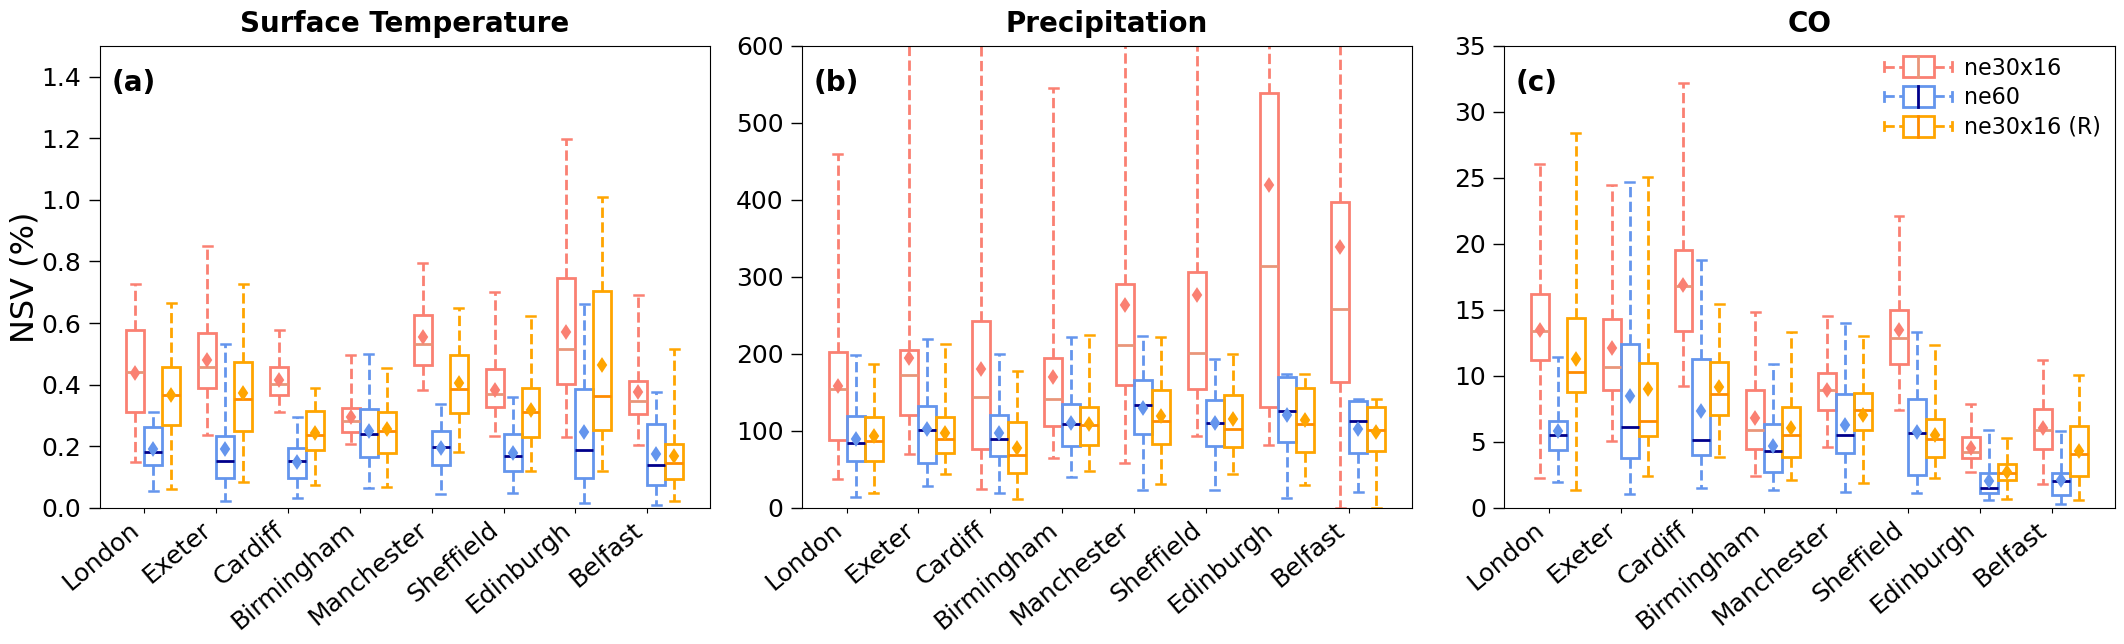

In [19]:

style_dicts = {
    'ne30x16': {
        'facecolor': 'none',
        'edgecolor': 'salmon',
        'box_linewidth': 2,
        'median_color': 'darksalmon',
        'median_linewidth': 2,
        'whisker_color': 'salmon',
        'whisker_linewidth': 2,
        'cap_color': 'salmon',
        'cap_linewidth': 1.8,
        'mean_markeredgecolor': 'salmon',
        'mean_markeredgewidth': 1.5,
        'box_width': 0.25
    },
    'ne60': {
        'facecolor': 'none',
        'edgecolor': 'cornflowerblue',
        'box_linewidth': 2,
        'median_color': 'darkblue',
        'median_linewidth': 2,
        'whisker_color': 'cornflowerblue',
        'whisker_linewidth': 2,
        'cap_color': 'cornflowerblue',
        'cap_linewidth': 1.8,
        'mean_markeredgecolor': 'cornflowerblue',
        'mean_markeredgewidth': 1.5,
        'box_width': 0.25
    },
    'regrid': {
        'facecolor': 'none',
        'edgecolor': 'orange',
        'box_linewidth': 2,
        'median_color': 'darkorange',
        'median_linewidth': 2,
        'whisker_color': 'orange',
        'whisker_linewidth': 2,
        'cap_color': 'orange',
        'cap_linewidth': 1.8,
        'mean_markeredgecolor': 'orange',
        'mean_markeredgewidth': 1.5,
        'box_width': 0.25
    }
}

fig, axes = plt.subplots(1, len(pollutants), figsize=(26, 6), constrained_layout=False)
for i, name in enumerate(pollutants):
    ax = axes[i]
    x = np.arange(len(cities))
    for j, cfg in enumerate(configs):
        cfg_name = cfg['name']
        stats = all_stats[cfg_name]
        data = [stats[city][name]['nsv'] * 100 for city in cities]
        sty = style_dicts[cfg_name]
        w = sty['box_width']
        positions = x + (j - 0.5) * w

        ax.boxplot(
            data,
            positions=positions,
            widths=w,
            whis=[0, 100],
            patch_artist=True,
            boxprops=dict(facecolor=sty['facecolor'],
                          edgecolor=sty['edgecolor'],
                          linewidth=sty['box_linewidth']),
            medianprops=dict(color=sty['median_color'],
                             linewidth=sty['median_linewidth']),
            whiskerprops=dict(color=sty['whisker_color'],
                              linewidth=sty['whisker_linewidth'],
                              linestyle='--'),
            capprops=dict(color=sty['cap_color'],
                          linewidth=sty['cap_linewidth']),
            showmeans=True,
            meanprops={
                'marker': 'd',
                'markerfacecolor': 'white',
                'markerfacecolor': sty['mean_markeredgecolor'],
                'markeredgecolor': sty['mean_markeredgecolor'],
                'markeredgewidth': sty['mean_markeredgewidth'],
                'markersize': 6.2
            })
        ax.set_title(name, fontsize=20, pad=10, fontweight='bold')
    if i == 0:
        ax.set_ylabel("NSV (%)", fontsize=23, labelpad=0.5)
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.tick_params(axis='y', which='major', labelsize=18, pad=5, length=8, width=1 )
        # ax.set_ylim(0, 133),
        ax.set_ylim(0, 1.5)
        # ax.set_ylim(-160, 25)

    elif i == 2:
        ax.set_ylabel("")
        ax.tick_params(axis='y', which='major', labelsize=18, pad=5, length=8, width=1 )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False),
        # ax.set_ylim(0, 39)
        ax.set_ylim(0, 35)
        
    elif i == 1:
        ax.set_ylabel("")
        ax.tick_params(axis='y', which='major', labelsize=18, pad=5, length=8, width=1 )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False),
        # ax.yaxis.set_major_locator(MultipleLocator(5))
        # ax.set_ylim(0, 48) 
        ax.set_ylim(0, 600)
        ax.yaxis.set_major_locator(MultipleLocator(100))

    if i == 2:
        class Ne30Handle: pass
        class Ne60Handle: pass
        class RegridHandle: pass
        class ObsHandle: pass
        h_ne30    = Ne30Handle()
        h_ne60    = Ne60Handle()
        h_regrid  = RegridHandle()
        handles = [h_ne30, h_ne60, h_regrid]
        labels  = ['ne30x16', 'ne60', 'ne30x16 (R)']
        handler_map = {
            Ne30Handle: HandlerBoxPlot(
                               sx=1.0, sy=1.8, 
                              lw=style_dicts['ne30x16']['box_linewidth'],
                              box_w_frac=style_dicts['ne30x16']['box_width']*1.6,
                              whisk_out_frac=style_dicts['ne30x16']['whisker_linewidth']*0.3,
                                edgecolor     = style_dicts['ne30x16']['edgecolor'],
                                median_color  = style_dicts['ne30x16']['median_color'],
                                whisker_color = style_dicts['ne30x16']['whisker_color'],
                                cap_color     = style_dicts['ne30x16']['cap_color']
                          ),
            Ne60Handle: HandlerBoxPlot(
                               sx=1.0, sy=1.8,
                              lw=style_dicts['ne60']['box_linewidth'],
                              box_w_frac=style_dicts['ne60']['box_width']*1.6,
                              whisk_out_frac=style_dicts['ne60']['whisker_linewidth']*0.3,
                                edgecolor     = style_dicts['ne60']['edgecolor'],
                                median_color  = style_dicts['ne60']['median_color'],
                                whisker_color = style_dicts['ne60']['whisker_color'],
                                cap_color     = style_dicts['ne60']['cap_color']
                          ),
            RegridHandle: HandlerBoxPlot(
                              sx=1.0, sy=1.8, 
                              lw=style_dicts['regrid']['box_linewidth'],
                              box_w_frac=style_dicts['regrid']['box_width']*1.6,
                              whisk_out_frac=style_dicts['regrid']['whisker_linewidth']*0.3,
                                edgecolor     = style_dicts['regrid']['edgecolor'],
                                median_color  = style_dicts['regrid']['median_color'],
                                whisker_color = style_dicts['regrid']['whisker_color'],
                                cap_color     = style_dicts['regrid']['cap_color'],
                                whisker_linestyle='--'
                          )}

        ax.legend(
            handles, labels,
            handler_map=handler_map,
            loc='upper right',
            bbox_to_anchor=(1.01, 1.02),
            fontsize=16,
            frameon=False,
            handlelength=3.5,
            handletextpad=0.3,
            labelspacing=0.3)
      
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=40, ha='right',fontsize=18)
    letter = chr(ord('a') + i)  # 'a', 'b', 'c'
    ax.text(
        0.02, 0.95,           
        f'({letter})',
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold',
        va='top', ha='left'
    )
plt.subplots_adjust(wspace=0.15)


In [10]:

configs = [
    {'name': 'ne30x16',
        'se_base_files': (
            "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/"
            "MUSICA_production3.2_BB/atm/hist/"
            "MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc",
        'start_date': datetime.date(2018, 5, 27),
        'end_date':   datetime.date(2018, 5, 30),
        'city_lonlat': {'London':     [360 - 0.1319, 51.4947],
                        'Exeter':     [360 - 3.5325, 50.7251],
                        'Cardiff':    [360 - 3.1763, 51.4817],
                        'Birmingham': [360 - 1.9182, 52.4813],
                        'Manchester': [360 - 2.2379, 53.4815],
                        'Sheffield':  [360 - 1.4781, 53.3786],
                        'Edinburgh':  [360 - 3.1822, 55.9456],
                        'Belfast':    [360 - 5.9288, 54.5997]}},
    {'name': 'ne60',
        'se_base_files': (
           "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/"
           "MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc",
        'start_date': datetime.date(2018, 5, 27),
        'end_date':   datetime.date(2018, 5, 30),
        'city_lonlat': {'London':     [360 - 0.1319, 51.4947],
                        'Exeter':     [360 - 3.5325, 50.7251],
                        'Cardiff':    [360 - 3.1763, 51.4817],
                        'Birmingham': [360 - 1.9182, 52.4813],
                        'Manchester': [360 - 2.2379, 53.4815],
                        'Sheffield':  [360 - 1.4781, 53.3786],
                        'Edinburgh':  [360 - 3.1822, 55.9456],
                        'Belfast':    [360 - 5.9288, 54.5997]}},
    {'name': 'regrid',
        'se_base_files': (
            "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regridded/"
            "regrid_to_ne60_MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc",
        'start_date': datetime.date(2018, 5, 27),
        'end_date':   datetime.date(2018, 5, 30),
        'city_lonlat': {'London':     [360 - 0.1319, 51.4947],
                        'Exeter':     [360 - 3.5325, 50.7251],
                        'Cardiff':    [360 - 3.1763, 51.4817],
                        'Birmingham': [360 - 1.9182, 52.4813],
                        'Manchester': [360 - 2.2379, 53.4815],
                        'Sheffield':  [360 - 1.4781, 53.3786],
                        'Edinburgh':  [360 - 3.1822, 55.9456],
                        'Belfast':    [360 - 5.9288, 54.5997]}},
]

cities = [
    'London', 'Exeter', 'Cardiff', 'Birmingham','Manchester', 'Sheffield', 'Edinburgh', 'Belfast']

vars_model = {
    # r'PM$_{2.5}$': 'PM25',
    # r'O$_3$':      'O3',
    # 'BC':          'BURDENBCdn'
    
    # 'Surface Temperature': 'T',
    # 'Precipitation':    'PRECT',
    # 'CO':        'CO',
    
    'Wind Speed (U)': 'U',
    'Wind Speed (V)':  'V',
    'CO':        'CO',
}


In [11]:

all_stats = {}
for cfg in configs:
    all_stats[cfg['name']] = load_and_compute_stats(
        cfg, cities, vars_model, box_deg=1.0, buffer_deg=0.2)
pollutants = list(vars_model.keys())

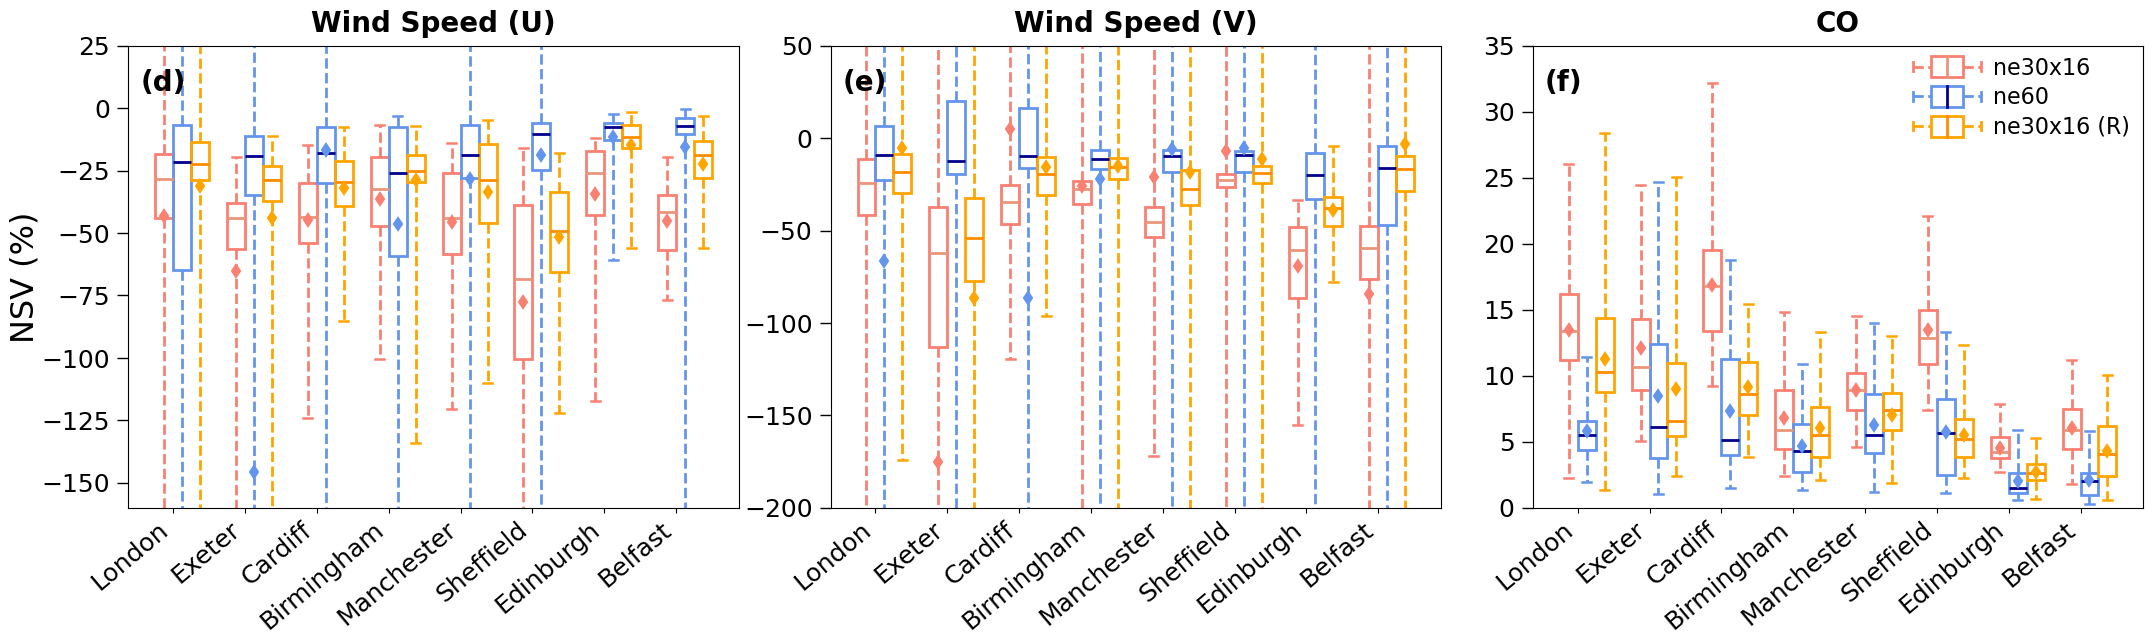

In [ ]:

style_dicts = {
    'ne30x16': {
        'facecolor': 'none',
        'edgecolor': 'salmon',
        'box_linewidth': 2,
        'median_color': 'darksalmon',
        'median_linewidth': 2,
        'whisker_color': 'salmon',
        'whisker_linewidth': 2,
        'cap_color': 'salmon',
        'cap_linewidth': 1.8,
        'mean_markeredgecolor': 'salmon',
        'mean_markeredgewidth': 1.5,
        'box_width': 0.25
    },
    'ne60': {
        'facecolor': 'none',
        'edgecolor': 'cornflowerblue',
        'box_linewidth': 2,
        'median_color': 'darkblue',
        'median_linewidth': 2,
        'whisker_color': 'cornflowerblue',
        'whisker_linewidth': 2,
        'cap_color': 'cornflowerblue',
        'cap_linewidth': 1.8,
        'mean_markeredgecolor': 'cornflowerblue',
        'mean_markeredgewidth': 1.5,
        'box_width': 0.25
    },
    'regrid': {
        'facecolor': 'none',
        'edgecolor': 'orange',
        'box_linewidth': 2,
        'median_color': 'darkorange',
        'median_linewidth': 2,
        'whisker_color': 'orange',
        'whisker_linewidth': 2,
        'cap_color': 'orange',
        'cap_linewidth': 1.8,
        'mean_markeredgecolor': 'orange',
        'mean_markeredgewidth': 1.5,
        'box_width': 0.25
    }
}

fig, axes = plt.subplots(1, len(pollutants), figsize=(26, 6), constrained_layout=False)
for i, name in enumerate(pollutants):
    ax = axes[i]
    x = np.arange(len(cities))
    for j, cfg in enumerate(configs):
        cfg_name = cfg['name']
        stats = all_stats[cfg_name]
        data = [stats[city][name]['nsv'] * 100 for city in cities]
        sty = style_dicts[cfg_name]
        w = sty['box_width']
        positions = x + (j - 0.5) * w

        ax.boxplot(
            data,
            positions=positions,
            widths=w,
            whis=[0, 100],
            patch_artist=True,
            boxprops=dict(facecolor=sty['facecolor'],
                          edgecolor=sty['edgecolor'],
                          linewidth=sty['box_linewidth']),
            medianprops=dict(color=sty['median_color'],
                             linewidth=sty['median_linewidth']),
            whiskerprops=dict(color=sty['whisker_color'],
                              linewidth=sty['whisker_linewidth'],
                              linestyle='--'),
            capprops=dict(color=sty['cap_color'],
                          linewidth=sty['cap_linewidth']),
            showmeans=True,
            meanprops={
                'marker': 'd',
                'markerfacecolor': 'white',
                'markerfacecolor': sty['mean_markeredgecolor'],
                'markeredgecolor': sty['mean_markeredgecolor'],
                'markeredgewidth': sty['mean_markeredgewidth'],
                'markersize': 6.2
            })
        ax.set_title(name, fontsize=20, pad=10, fontweight='bold')
    if i == 0:
        ax.set_ylabel("NSV (%)", fontsize=23, labelpad=0.5)
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.tick_params(axis='y', which='major', labelsize=18, pad=5, length=8, width=1 )
        # ax.set_ylim(0, 133),
        # ax.set_ylim(0, 1.5)
        ax.set_ylim(-160, 25)

    elif i == 2:
        ax.set_ylabel("")
        ax.tick_params(axis='y', which='major', labelsize=18, pad=5, length=8, width=1 )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False),
        # ax.set_ylim(0, 39)
        ax.set_ylim(0, 35)
        
    elif i == 1:
        ax.set_ylabel("")
        ax.tick_params(axis='y', which='major', labelsize=18, pad=5, length=8, width=1 )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False),
        # ax.yaxis.set_major_locator(MultipleLocator(5))
        # ax.set_ylim(0, 48) 
        # ax.set_ylim(0, 600)
        ax.set_ylim(-200, 50)
        ax.yaxis.set_major_locator(MultipleLocator(50))

    if i == 2:
        class Ne30Handle: pass
        class Ne60Handle: pass
        class RegridHandle: pass
        class ObsHandle: pass
        h_ne30    = Ne30Handle()
        h_ne60    = Ne60Handle()
        h_regrid  = RegridHandle()
        handles = [h_ne30, h_ne60, h_regrid]
        labels  = ['ne30x16', 'ne60', 'ne30x16 (R)']
        handler_map = {
            Ne30Handle: HandlerBoxPlot(
                               sx=1.0, sy=1.8, 
                              lw=style_dicts['ne30x16']['box_linewidth'],
                              box_w_frac=style_dicts['ne30x16']['box_width']*1.6,
                              whisk_out_frac=style_dicts['ne30x16']['whisker_linewidth']*0.3,
                                edgecolor     = style_dicts['ne30x16']['edgecolor'],
                                median_color  = style_dicts['ne30x16']['median_color'],
                                whisker_color = style_dicts['ne30x16']['whisker_color'],
                                cap_color     = style_dicts['ne30x16']['cap_color']
                          ),
            Ne60Handle: HandlerBoxPlot(
                               sx=1.0, sy=1.8,
                              lw=style_dicts['ne60']['box_linewidth'],
                              box_w_frac=style_dicts['ne60']['box_width']*1.6,
                              whisk_out_frac=style_dicts['ne60']['whisker_linewidth']*0.3,
                                edgecolor     = style_dicts['ne60']['edgecolor'],
                                median_color  = style_dicts['ne60']['median_color'],
                                whisker_color = style_dicts['ne60']['whisker_color'],
                                cap_color     = style_dicts['ne60']['cap_color']
                          ),
            RegridHandle: HandlerBoxPlot(
                              sx=1.0, sy=1.8, 
                              lw=style_dicts['regrid']['box_linewidth'],
                              box_w_frac=style_dicts['regrid']['box_width']*1.6,
                              whisk_out_frac=style_dicts['regrid']['whisker_linewidth']*0.3,
                                edgecolor     = style_dicts['regrid']['edgecolor'],
                                median_color  = style_dicts['regrid']['median_color'],
                                whisker_color = style_dicts['regrid']['whisker_color'],
                                cap_color     = style_dicts['regrid']['cap_color'],
                                whisker_linestyle='--'
                          )}

        ax.legend(
            handles, labels,
            handler_map=handler_map,
            loc='upper right',
            bbox_to_anchor=(1.01, 1.02),
            fontsize=16,
            frameon=False,
            handlelength=3.5,
            handletextpad=0.3,
            labelspacing=0.3)
      
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=40, ha='right',fontsize=18)
    letter = chr(ord('d') + i)  # 'a', 'b', 'c'
    ax.text(
        0.02, 0.95,           
        f'({letter})',
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold',
        va='top', ha='left'
    )
plt.subplots_adjust(wspace=0.15)

